# Model Comparison: Custom CNN vs Transfer Learning

This notebook compares the performance of the Custom CNN baseline model with the Transfer Learning model.

## Overview

- **Overall Metrics**: Accuracy, Precision, Recall, F1-Score (weighted and macro)
- **Per-Class Metrics**: Detailed comparison for each class
- **Visualizations**: Bar charts and comparison plots
- **Summary Report**: Key findings and improvements


In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

# Import comparison tools
from compare_models import ModelComparator
from model_serialization import ModelSerializer

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

2025-12-23 17:38:22.795512: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-23 17:38:23.124085: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-23 17:38:25.482748: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Load Metrics

Load metrics from both models. You can either:
- Use default metrics (update values below)
- Load from saved model packages
- Load from JSON files


In [2]:
# Load metrics from saved model files
serializer = ModelSerializer()
models_dir = Path('models/saved_models')

def find_latest_model(version='1.0'):
    """Find the latest saved model with given version"""
    if not models_dir.exists():
        raise FileNotFoundError(f"Models directory not found: {models_dir}")
    
    version_str = f'v{version}'
    matching_models = []
    
    for model_dir in models_dir.iterdir():
        if model_dir.is_dir() and version_str in model_dir.name:
            try:
                # Extract timestamp from directory name (format: covid19_model_vX.X_YYYYMMDD_HHMMSS)
                parts = model_dir.name.split('_')
                if len(parts) >= 3:
                    date_str, time_str = parts[-2], parts[-1]
                    timestamp = datetime.strptime(f"{date_str}_{time_str}", "%Y%m%d_%H%M%S")
                    matching_models.append((timestamp, model_dir))
            except (ValueError, IndexError):
                continue
    
    if not matching_models:
        raise FileNotFoundError(f"No model found with version {version_str} in {models_dir}")
    
    # Return the latest model (newest timestamp)
    matching_models.sort(key=lambda x: x[0], reverse=True)
    return matching_models[0][1]

def format_metric(value, default='N/A'):
    """Format metric value for display"""
    if isinstance(value, (int, float)):
        return f"{value:.4f}"
    return default

# Load Custom CNN model (v1.0)
print("Loading Custom CNN model...")
try:
    custom_cnn_model_path = find_latest_model('1.0')
    print(f"  Found: {custom_cnn_model_path.name}")
    custom_cnn_package = serializer.load_model(custom_cnn_model_path)
    custom_cnn_metrics = custom_cnn_package['validation_metrics']
    print("  Metrics loaded successfully")
except Exception as e:
    raise RuntimeError(f"Failed to load Custom CNN model: {e}\n"
                      f"Please ensure you have saved a Custom CNN model (v1.0) using ModelSerializer.")

# Load Transfer Learning model (v2.0)
print("\nLoading Transfer Learning model...")
try:
    transfer_learning_model_path = find_latest_model('2.0')
    print(f"  Found: {transfer_learning_model_path.name}")
    tl_package = serializer.load_model(transfer_learning_model_path)
    transfer_learning_metrics = tl_package['validation_metrics']
    print("  Metrics loaded successfully")
except Exception as e:
    raise RuntimeError(f"Failed to load Transfer Learning model: {e}\n"
                      f"Please ensure you have saved a Transfer Learning model (v2.0) using ModelSerializer.")

# Extract class labels and normalize to integer keys
class_labels_raw = (tl_package['config'].get('class_labels') or 
                   custom_cnn_package['config'].get('class_labels'))

if not class_labels_raw:
    raise ValueError("No class labels found in either model. Cannot proceed with comparison.")

# Normalize class_labels to use integer keys (handle string keys from JSON)
class_labels = {}
for key, value in class_labels_raw.items():
    # Convert string keys to integers
    try:
        int_key = int(key)
        class_labels[int_key] = value
    except (ValueError, TypeError):
        # If key is already an int or can't convert, use as-is
        class_labels[key] = value

# Ensure we have integer keys 0, 1, 2, 3...
if all(isinstance(k, int) for k in class_labels.keys()):
    # Sort by key to ensure order
    class_labels = {i: class_labels[i] for i in sorted(class_labels.keys())}
else:
    # Convert string keys to int
    class_labels = {int(k): v for k, v in class_labels.items()}
    class_labels = {i: class_labels[i] for i in sorted(class_labels.keys())}

# Display summary
print("\n" + "=" * 60)
print("METRICS LOADED SUCCESSFULLY")
print("=" * 60)
print(f"Custom CNN Accuracy: {format_metric(custom_cnn_metrics.get('accuracy'))}")
print(f"Transfer Learning Accuracy: {format_metric(transfer_learning_metrics.get('accuracy'))}")
print(f"Number of classes: {len(class_labels)}")
print("=" * 60)


Loading Custom CNN model...
  Found: covid19_model_v1.0_20251221_174731
Loading model from: models/saved_models/covid19_model_v1.0_20251221_174731/covid19_model_v1.0_20251221_174731.joblib


I0000 00:00:1766533108.543719 1040158 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13510 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080, pci bus id: 0000:01:00.0, compute capability: 8.9
/root/Covid19-Project/venv/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


 Model loaded successfully!
   Version: 1.0
   Created: 2025-12-21T17:47:31.633786
   Input shape: [256, 256, 3]
  Metrics loaded successfully

Loading Transfer Learning model...
  Found: covid19_model_v2.0_20251221_174659
Loading model from: models/saved_models/covid19_model_v2.0_20251221_174659/covid19_model_v2.0_20251221_174659.joblib
 Model loaded successfully!
   Version: 2.0
   Created: 2025-12-21T17:46:59.348263
   Input shape: [256, 256, 3]
  Metrics loaded successfully

METRICS LOADED SUCCESSFULLY
Custom CNN Accuracy: 0.5793
Transfer Learning Accuracy: 0.5288
Number of classes: 4


/root/Covid19-Project/venv/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 106 variables whereas the saved optimizer has 110 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


### Manual Override (Optional)

If you want to manually specify model paths instead of using the latest models, uncomment and modify the code below:


In [3]:
# Optional: Manually specify model paths instead of using latest models
# Uncomment and modify the paths below if needed:
#
# custom_cnn_model_path = Path('models/saved_models/covid19_model_v1.0_YYYYMMDD_HHMMSS')
# transfer_learning_model_path = Path('models/saved_models/covid19_model_v2.0_YYYYMMDD_HHMMSS')
# 
# serializer = ModelSerializer()
# custom_cnn_package = serializer.load_model(custom_cnn_model_path)
# custom_cnn_metrics = custom_cnn_package['validation_metrics']
# 
# tl_package = serializer.load_model(transfer_learning_model_path)
# transfer_learning_metrics = tl_package['validation_metrics']
# 
# class_labels = (tl_package['config'].get('class_labels') or 
#                 custom_cnn_package['config'].get('class_labels'))

print("Using automatically loaded latest models from above.")


Using automatically loaded latest models from above.


In [ ]:
# Debug: Inspect metrics structure before comparison
print("=" * 60)
print("DEBUG: Metrics Structure")
print("=" * 60)
print("\nCustom CNN metrics keys:", list(custom_cnn_metrics.keys()))
print("Transfer Learning metrics keys:", list(transfer_learning_metrics.keys()))
print("\nClass labels:", class_labels)
print("Class labels type:", type(class_labels))
print("Class labels keys:", list(class_labels.keys())[:3], "...")
print("=" * 60)


DEBUG: Metrics Structure

Custom CNN metrics keys: ['accuracy', 'loss']
Transfer Learning metrics keys: ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'precision_macro', 'recall_macro', 'f1_macro', 'loss']

Class labels: {0: 'Negative for Pneumonia', 1: 'Typical Appearance', 2: 'Indeterminate Appearance', 3: 'Atypical Appearance'}
Class labels type: <class 'dict'>
Class labels keys: [0, 1, 2] ...


## 2. Run Model Comparison

Create ModelComparator and run full comparison analysis:


MODEL COMPARISON: TRANSFER LEARNING vs CUSTOM CNN
OVERALL METRICS COMPARISON
              Metric  Custom CNN  Transfer Learning  Improvement  Improvement %
            Accuracy    0.579321           0.528808    -0.050513          -8.72
Precision (Weighted)    0.000000           0.599264     0.599264            inf
   Recall (Weighted)    0.000000           0.528808     0.528808            inf
 F1-Score (Weighted)    0.000000           0.540736     0.540736            inf
   Precision (Macro)    0.000000           0.447063     0.447063            inf
      Recall (Macro)    0.000000           0.470843     0.470843            inf
    F1-Score (Macro)    0.000000           0.433265     0.433265            inf

✓ Comparison saved to: comparison_results/overall_metrics_comparison.csv
✓ Figure saved to: comparison_results/overall_metrics_comparison.png


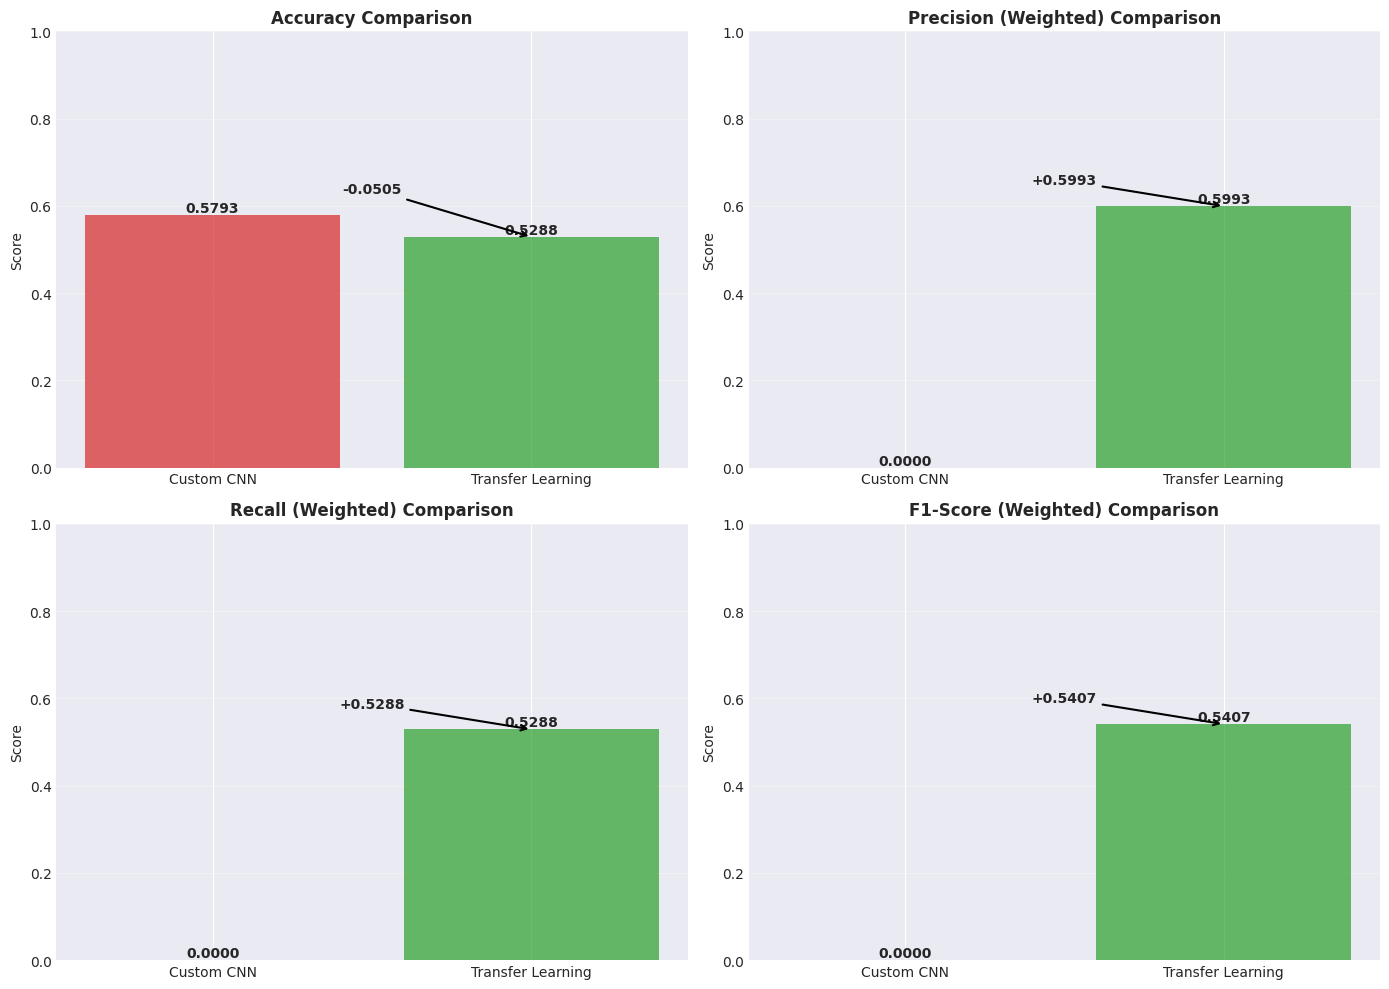


PER-CLASS METRICS COMPARISON
                   Class  CNN Precision  TL Precision  Precision Δ  CNN Recall  TL Recall  Recall Δ  CNN F1  TL F1  F1 Δ
  Negative for Pneumonia            0.0           0.0          0.0         0.0        0.0       0.0     0.0    0.0   0.0
      Typical Appearance            0.0           0.0          0.0         0.0        0.0       0.0     0.0    0.0   0.0
Indeterminate Appearance            0.0           0.0          0.0         0.0        0.0       0.0     0.0    0.0   0.0
     Atypical Appearance            0.0           0.0          0.0         0.0        0.0       0.0     0.0    0.0   0.0

✓ Per-class comparison saved to: comparison_results/per_class_metrics_comparison.csv
✓ Figure saved to: comparison_results/per_class_metrics_comparison.png


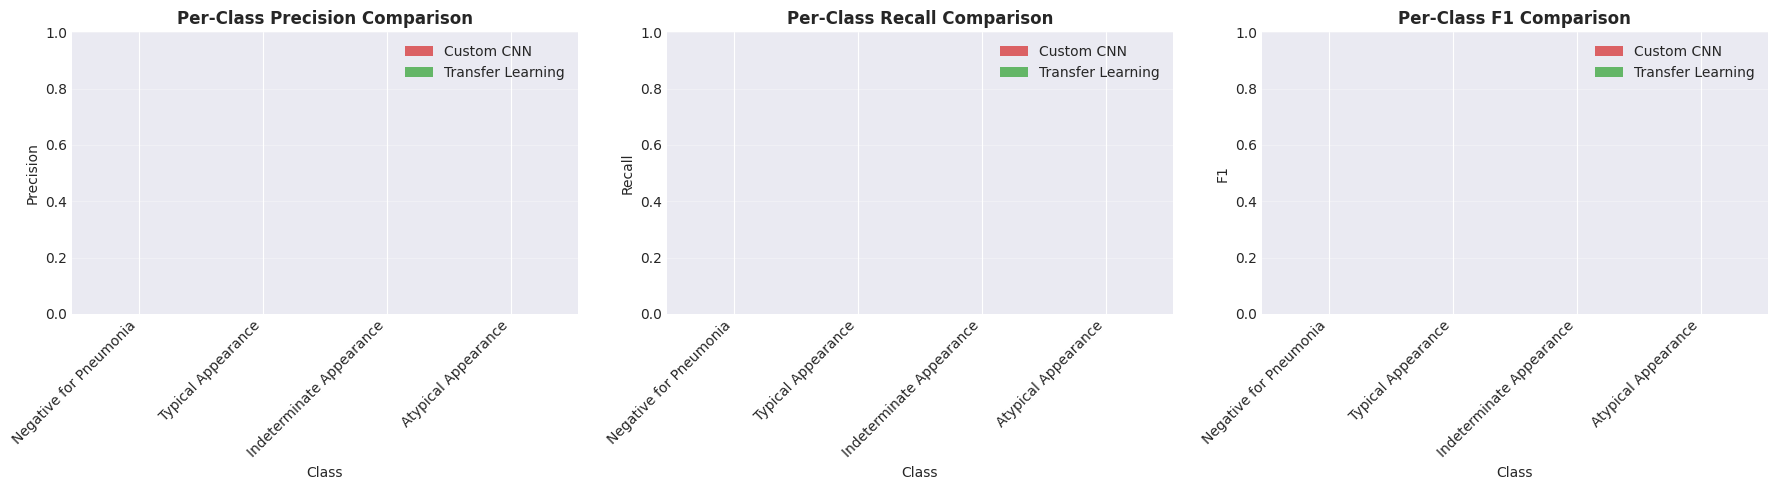


SUMMARY OF IMPROVEMENTS

Overall Metrics:
  Accuracy improvement: -0.0505 (-8.72%)
  Weighted F1 improvement: +0.5407 (+inf%)
  Macro F1 improvement: +0.4333 (+inf%)

Per-Class Improvements:

  Negative for Pneumonia:
    Precision: +0.0000
    Recall:    +0.0000
    F1-Score:  +0.0000

  Typical Appearance:
    Precision: +0.0000
    Recall:    +0.0000
    F1-Score:  +0.0000

  Indeterminate Appearance:
    Precision: +0.0000
    Recall:    +0.0000
    F1-Score:  +0.0000

  Atypical Appearance:
    Precision: +0.0000
    Recall:    +0.0000
    F1-Score:  +0.0000

KEY FINDINGS

Transfer learning did not significantly improve minority class performance

Overall accuracy decreased by 0.0505

✓ Summary saved to: comparison_results/comparison_summary.txt

COMPARISON COMPLETE!
All results saved to: comparison_results


In [5]:
# Create ModelComparator instance
output_dir = Path('comparison_results')
comparator = ModelComparator(
    custom_cnn_metrics=custom_cnn_metrics,
    transfer_learning_metrics=transfer_learning_metrics,
    class_labels=class_labels,
    output_dir=output_dir
)

# Run full comparison (includes overall metrics, per-class metrics, visualizations, and summary)
comparator.run_full_comparison()


In [ ]:
# Get comparison DataFrames for further analysis
comparison_df = comparator.compare_overall_metrics()
per_class_df = comparator.compare_per_class_metrics()

print("\n Comparison DataFrames available:")
print(f"  - comparison_df: Overall metrics comparison")
print(f"  - per_class_df: Per-class metrics comparison")


OVERALL METRICS COMPARISON
              Metric  Custom CNN  Transfer Learning  Improvement  Improvement %
            Accuracy    0.579321           0.528808    -0.050513          -8.72
Precision (Weighted)    0.000000           0.599264     0.599264            inf
   Recall (Weighted)    0.000000           0.528808     0.528808            inf
 F1-Score (Weighted)    0.000000           0.540736     0.540736            inf
   Precision (Macro)    0.000000           0.447063     0.447063            inf
      Recall (Macro)    0.000000           0.470843     0.470843            inf
    F1-Score (Macro)    0.000000           0.433265     0.433265            inf

✓ Comparison saved to: comparison_results/overall_metrics_comparison.csv

PER-CLASS METRICS COMPARISON
                   Class  CNN Precision  TL Precision  Precision Δ  CNN Recall  TL Recall  Recall Δ  CNN F1  TL F1  F1 Δ
  Negative for Pneumonia            0.0           0.0          0.0         0.0        0.0       0.0     0.0 

## 3. Additional Analysis (Optional)

If you need to perform additional analysis on the comparison results, you can access the DataFrames:


In [7]:
# Example: Display comparison DataFrames
print("=" * 60)
print("OVERALL METRICS COMPARISON")
print("=" * 60)
print(comparison_df.to_string(index=False))

print("\n" + "=" * 60)
print("PER-CLASS METRICS COMPARISON")
print("=" * 60)
print(per_class_df.to_string(index=False))


OVERALL METRICS COMPARISON
              Metric  Custom CNN  Transfer Learning  Improvement  Improvement %
            Accuracy    0.579321           0.528808    -0.050513          -8.72
Precision (Weighted)    0.000000           0.599264     0.599264            inf
   Recall (Weighted)    0.000000           0.528808     0.528808            inf
 F1-Score (Weighted)    0.000000           0.540736     0.540736            inf
   Precision (Macro)    0.000000           0.447063     0.447063            inf
      Recall (Macro)    0.000000           0.470843     0.470843            inf
    F1-Score (Macro)    0.000000           0.433265     0.433265            inf

PER-CLASS METRICS COMPARISON
                   Class  CNN Precision  TL Precision  Precision Δ  CNN Recall  TL Recall  Recall Δ  CNN F1  TL F1  F1 Δ
  Negative for Pneumonia            0.0           0.0          0.0         0.0        0.0       0.0     0.0    0.0   0.0
      Typical Appearance            0.0           0.0        

In [ ]:
# Optional: Regenerate visualizations separately if needed
# comparator.visualize_overall_metrics(comparison_df)
# comparator.visualize_per_class_metrics(per_class_df)

print("✓ All visualizations have been generated and saved to the output directory.")


✓ All visualizations have been generated and saved to the output directory.


## 4. Summary Report

The summary report has already been generated by `run_full_comparison()`. 
All results have been saved to the output directory.


In [ ]:
# Optional: Regenerate summary report if needed
comparator.generate_summary_report(comparison_df, per_class_df)
print("Summary report generated.")



SUMMARY OF IMPROVEMENTS

Overall Metrics:
  Accuracy improvement: -0.0505 (-8.72%)
  Weighted F1 improvement: +0.5407 (+inf%)
  Macro F1 improvement: +0.4333 (+inf%)

Per-Class Improvements:

  Negative for Pneumonia:
    Precision: +0.0000
    Recall:    +0.0000
    F1-Score:  +0.0000

  Typical Appearance:
    Precision: +0.0000
    Recall:    +0.0000
    F1-Score:  +0.0000

  Indeterminate Appearance:
    Precision: +0.0000
    Recall:    +0.0000
    F1-Score:  +0.0000

  Atypical Appearance:
    Precision: +0.0000
    Recall:    +0.0000
    F1-Score:  +0.0000

KEY FINDINGS

Transfer learning did not significantly improve minority class performance

Overall accuracy decreased by 0.0505

✓ Summary saved to: comparison_results/comparison_summary.txt
Summary report generated.


## 5. Results Saved

All comparison results have been automatically saved by `ModelComparator`:
- Overall metrics comparison (CSV and PNG)
- Per-class metrics comparison (CSV and PNG)
- Summary report (TXT)

Files are saved in the `comparison_results` directory.


In [10]:
# List all saved comparison files
print("=" * 60)
print("SAVED FILES")
print("=" * 60)
saved_files = sorted([f for f in output_dir.glob('*') if f.is_file()])
if saved_files:
    for file in saved_files:
        size_kb = file.stat().st_size / 1024
        print(f"  {file.name} ({size_kb:.2f} KB)")
else:
    print("  No files found in output directory.")
print("=" * 60)


SAVED FILES
  comparison_summary.txt (0.62 KB)
  overall_metrics_comparison.csv (0.51 KB)
  overall_metrics_comparison.png (245.64 KB)
  per_class_metrics_comparison.csv (0.32 KB)
  per_class_metrics_comparison.png (202.16 KB)
